<a href="https://colab.research.google.com/github/DariyaSavva/dsp-seminars/blob/savva_dariya_lab_3/seminars/3_savva_dariya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

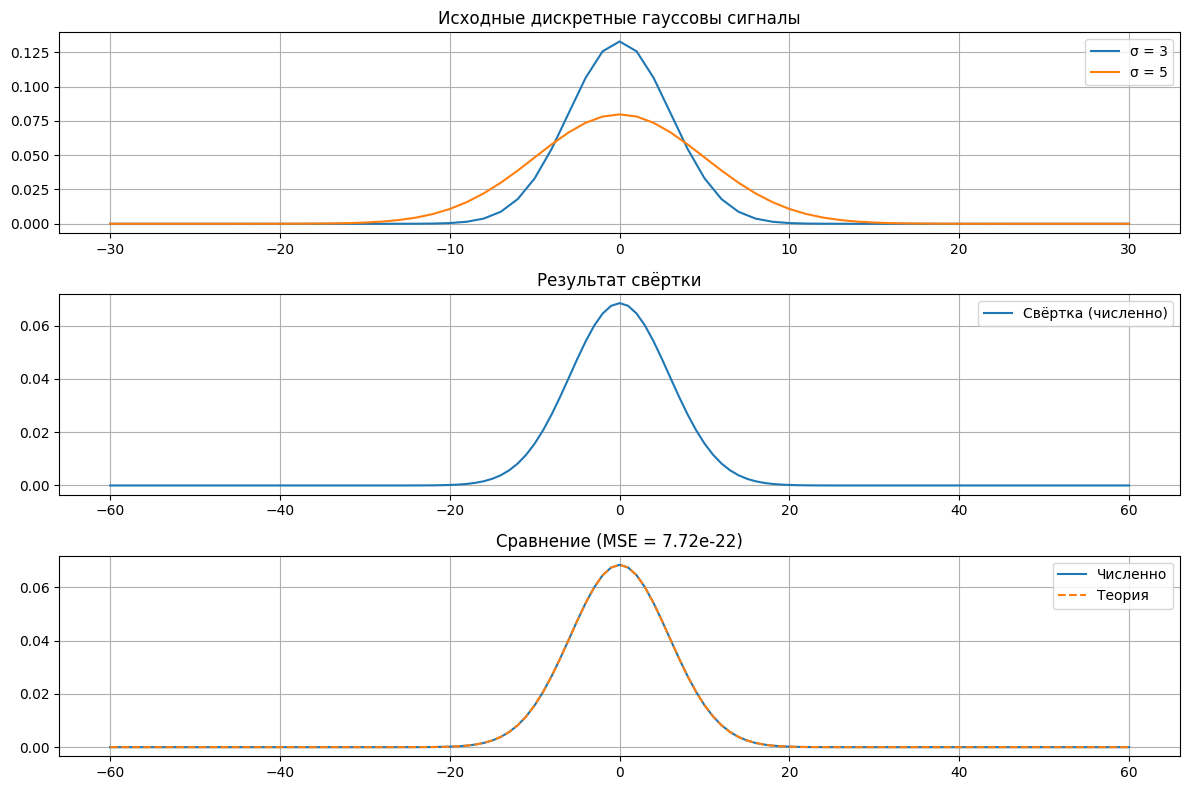

Итоговое σ = 5.831
MSE = 7.718540e-22


In [38]:
from scipy.signal.windows import gaussian
# параметры
sigma_a = 3
sigma_b = 5
dt = 1.0

# временная ось
T = int(6 * max(sigma_a, sigma_b))
time = np.arange(-T, T + dt, dt)
N = len(time)

# генерация дискретных гауссиан
win_a = gaussian(N, std=sigma_a / dt)
win_b = gaussian(N, std=sigma_b / dt)

# нормировка (как плотность)
gauss_a = win_a / (np.sum(win_a) * dt)
gauss_b = win_b / (np.sum(win_b) * dt)

# свёртка
conv_num = np.convolve(gauss_a, gauss_b, mode='full') * dt

# новая ось
time_conv = np.arange(time[0] + time[0], time[-1] + time[-1] + dt, dt)

# теория
sigma_total = np.sqrt(sigma_a**2 + sigma_b**2)
conv_theory = (1 / (np.sqrt(2 * np.pi) * sigma_total)) * np.exp(-time_conv**2 / (2 * sigma_total**2))

# ошибка
mse = np.mean((conv_num - conv_theory) ** 2)

# графики
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(time, gauss_a, label='σ = 3')
plt.plot(time, gauss_b, label='σ = 5')
plt.title('Исходные дискретные гауссовы сигналы')
plt.grid()
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time_conv, conv_num, label='Свёртка (численно)')
plt.title('Результат свёртки')
plt.grid()
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(time_conv, conv_num, label='Численно')
plt.plot(time_conv, conv_theory, '--', label='Теория')
plt.title(f'Сравнение (MSE = {mse:.2e})')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговое σ = {sigma_total:.3f}")
print(f"MSE = {mse:.6e}")

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

{При увеличении σ свёртка становится шире, а пик понижается, кривая как бы растягивается по времени.}

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

L    | Окно         | Ампл. 5 Гц (исх=1)   | Ампл. 80 Гц (исх=0.5)
-----------------------------------------------------------------
11   | Прямоугол.   | 0.9951               | 0.0678              
11   | Гауссовск.   | 0.9978               | 0.2804              
21   | Прямоугол.   | 0.9822               | 0.0800              
21   | Гауссовск.   | 0.9922               | 0.0502              


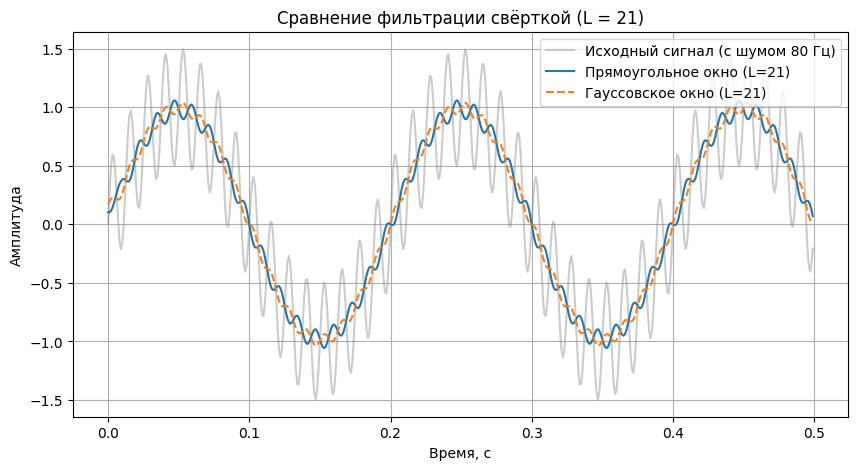

41   | Прямоугол.   | 0.9330               | 0.0367              
41   | Гауссовск.   | 0.9704               | 0.0005              
81   | Прямоугол.   | 0.7542               | 0.0254              
81   | Гауссовск.   | 0.8891               | 0.0028              


In [39]:

from scipy.fft import fft, fftfreq
from scipy.signal.windows import boxcar, gaussian

# 1. Параметры исходного сигнала
fs = 1000
t = np.arange(0, 2, 1/fs)
f1 = 5
f2 = 80

# Сигнал: 5 Гц (амплитуда 1) + 80 Гц (амплитуда 0.5)
signal = 1.0 * np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

# Вспомогательная функция для поиска амплитуд через БПФ
def get_amplitudes(sig):
    N = len(sig)
    yf = fft(sig)
    xf = fftfreq(N, 1/fs)

    # Ищем индексы нужных нам частот в массиве
    idx_5 = np.argmin(np.abs(xf - f1))
    idx_80 = np.argmin(np.abs(xf - f2))

    # Считаем реальную амплитуду
    amp_5 = 2.0/N * np.abs(yf[idx_5])
    amp_80 = 2.0/N * np.abs(yf[idx_80])

    return amp_5, amp_80

# 2. Исследование для разных длин окон
L_values = [11, 21, 41, 81]

print(f"{'L':<4} | {'Окно':<12} | {'Ампл. 5 Гц (исх=1)':<20} | {'Ампл. 80 Гц (исх=0.5)':<20}")
print("-" * 65)

for L in L_values:
    # Генерируем окна и сразу их нормализуем (сумма = 1)
    w_box = boxcar(L)
    w_box = w_box / np.sum(w_box)

    w_gauss = gaussian(L, std=L/5)
    w_gauss = w_gauss / np.sum(w_gauss)

    # Применяем свёртку (mode='same' чтобы длина сигнала не изменилась)
    filt_box = np.convolve(signal, w_box, mode='same')
    filt_gauss = np.convolve(signal, w_gauss, mode='same')

    # Получаем амплитуды
    amp_5_box, amp_80_box = get_amplitudes(filt_box)
    amp_5_gauss, amp_80_gauss = get_amplitudes(filt_gauss)

    # Выводим табличку
    print(f"{L:<4} | {'Прямоугол.':<12} | {amp_5_box:<20.4f} | {amp_80_box:<20.4f}")
    print(f"{L:<4} | {'Гауссовск.':<12} | {amp_5_gauss:<20.4f} | {amp_80_gauss:<20.4f}")

    # 3. Графики строим только для L=21
    if L == 21:
        plt.figure(figsize=(10, 5))

        # Берём только первые 0.5 секунды
        idx_05 = int(0.5 * fs)

        plt.plot(t[:idx_05], signal[:idx_05], label='Исходный сигнал (с шумом 80 Гц)', alpha=0.4, color='gray')
        plt.plot(t[:idx_05], filt_box[:idx_05], label='Прямоугольное окно (L=21)')
        plt.plot(t[:idx_05], filt_gauss[:idx_05], label='Гауссовское окно (L=21)', linestyle='--')

        plt.title('Сравнение фильтрации свёрткой (L = 21)')
        plt.xlabel('Время, с')
        plt.ylabel('Амплитуда')
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты?

{
  - гауссовское даёт лучшее подавление высоких частот: в выведенной таблице высокочастотная (80 Гц) амплитуда убывает сильнее для гауссовского окна, особенно видна разница при больших L.
- исходная высокочастотная амплитуда равна 0.5, для гауссовского окна она падает почти в 10 раз при длине L = 21, и падает более чем в 10 раз для L=41 и выше. для прямоугольного падение чуть больше чем в 10 раз достигается только при L=81. таким образом падение амплитуды высокочстотной составляющей происходит для гауссовского окна быстрее (то есть на меньших длинах) в сравнении с прямоугольным.
- Чем больше L, тем сильнее подавляется амплитуда низкой частоты. Для прямоугольного окна это подавление сильнее чем при такой же длине гауссовского окна.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

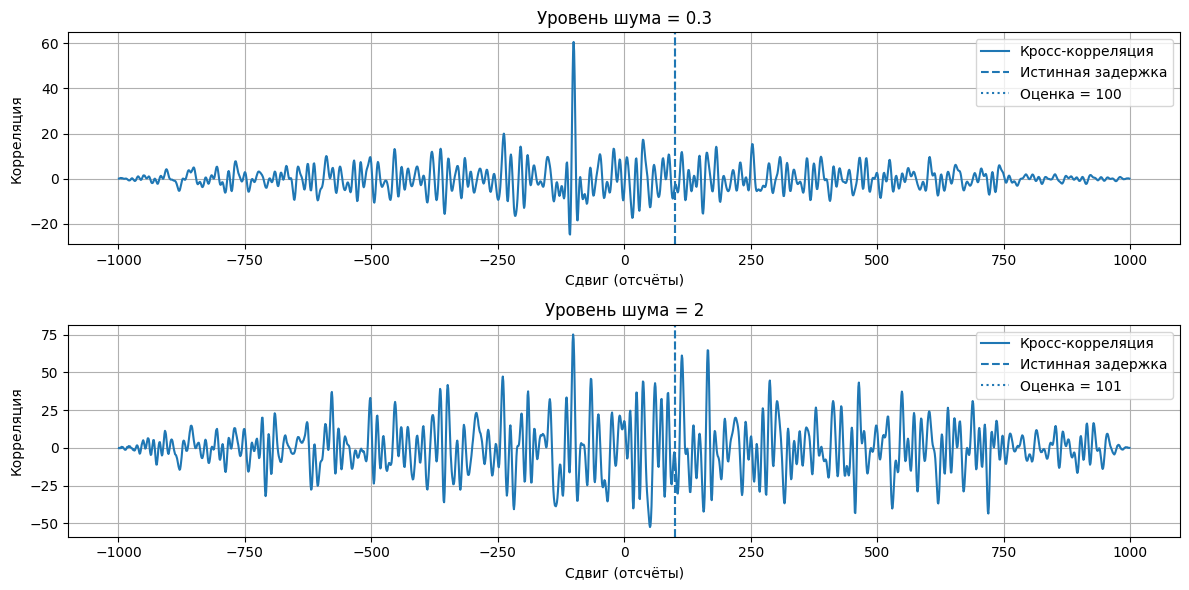

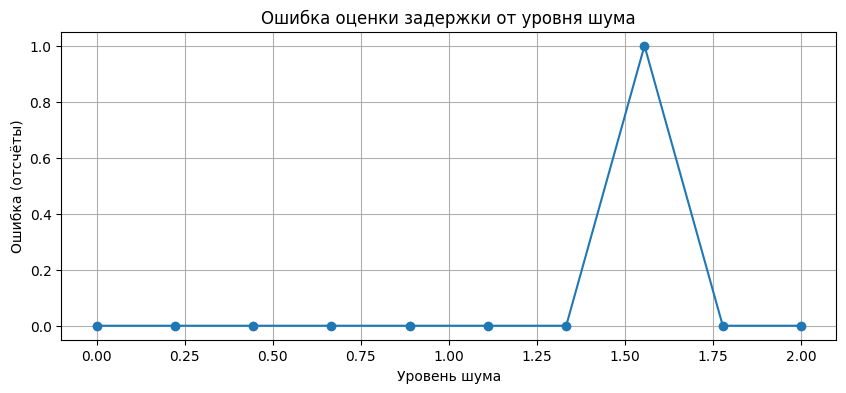

Истинная задержка: 100

Результаты:
noise = 0.00 → оценка = 100
noise = 0.22 → оценка = 100
noise = 0.44 → оценка = 100
noise = 0.67 → оценка = 100
noise = 0.89 → оценка = 100
noise = 1.11 → оценка = 100
noise = 1.33 → оценка = 100
noise = 1.56 → оценка = 101
noise = 1.78 → оценка = 100
noise = 2.00 → оценка = 100


In [40]:
T = 1
t = np.arange(0, T, 1/fs)
N = len(t)

np.random.seed(42)  # для воспроизводимости

num_sines = 100

# случайные параметры
freqs = np.random.uniform(10, 100, num_sines)
amps = np.random.uniform(0.5, 1.5, num_sines)
phases = np.random.uniform(0, 2*np.pi, num_sines)

# формируем сигнал
x = np.zeros_like(t)
for f, a, p in zip(freqs, amps, phases):
    x += a * np.sin(2 * np.pi * f * t + p)

# нормализация в [-1, 1]
x = x / np.max(np.abs(x))


true_delay = 100  # в отсчётах

# сдвиг
#y_clean = np.roll(x, true_delay)
y_clean = np.zeros_like(x)
y_clean[true_delay:] = x[:-true_delay]

def estimate_delay(x, y):
    corr = np.correlate(x, y, mode='full')
    lag = np.arange(-len(x)+1, len(x))

    delay_est = -lag[np.argmax(corr)]
    return delay_est, corr, lag


noise_levels = np.linspace(0, 2, 10)

estimated_delays = []

for nl in noise_levels:
    noise = nl * np.random.randn(N)
    y_noisy = y_clean + noise

    delay_est, _, _ = estimate_delay(x, y_noisy)
    estimated_delays.append(delay_est)

plot_levels = [0.3, 2]

plt.figure(figsize=(12, 6))

for i, nl in enumerate(plot_levels, 1):
    noise = nl * np.random.randn(N)
    y_noisy = y_clean + noise

    delay_est, corr, lag = estimate_delay(x, y_noisy)

    plt.subplot(2, 1, i)
    plt.plot(lag, corr, label='Кросс-корреляция')

    # истинная задержка
    plt.axvline(true_delay, linestyle='--', label='Истинная задержка')

    # найденная задержка
    plt.axvline(delay_est, linestyle=':', label=f'Оценка = {delay_est}')

    plt.title(f'Уровень шума = {nl}')
    plt.xlabel('Сдвиг (отсчёты)')
    plt.ylabel('Корреляция')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


errors = np.abs(np.array(estimated_delays) - true_delay)

plt.figure(figsize=(10, 4))
plt.plot(noise_levels, errors, marker='o')
plt.title('Ошибка оценки задержки от уровня шума')
plt.xlabel('Уровень шума')
plt.ylabel('Ошибка (отсчёты)')
plt.grid(True)
plt.show()

print("Истинная задержка:", true_delay)
print("\nРезультаты:")
for nl, d in zip(noise_levels, estimated_delays):
    print(f"noise = {nl:.2f} → оценка = {d}")

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

{
  - точность остаётся очень высокой на всём диапазоне шума 0–2. Даже при уровне шума 2.0 (в 2 раза превышающем амплитуду сигнала) ошибка не превышает 1 отсчёт, задержка не отличается от истинной ни при каком диапазоне шума и никогда не становится близкой к 0
  - Ложные пики при высоком уровне шума возникают из-за случайных совпадений между участками полезного сигнала и выбросами шума в процессе вычисления кросс-корреляции.  В проведённом эксперименте (шум 0–2) ложные пики практически не наблюдались благодаря использованию сигнала со случайными фазами."
}

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

Амплитуда |  SNR, дБ | Истинная | Найдена | Ошибка
--------------------------------------------------
     0.20 |    -22.2 |     1031 |     881 |    150
     0.60 |    -12.7 |       59 |      60 |      1
     1.00 |     -8.2 |      555 |     554 |      1
     1.40 |     -5.3 |     1082 |    1081 |      1
     1.80 |     -3.1 |      721 |     721 |      0
     2.20 |     -1.4 |      503 |     503 |      0
     2.60 |      0.1 |      374 |     373 |      1
     3.00 |      1.3 |        8 |       8 |      0
     3.40 |      2.4 |     1054 |    1054 |      0
     3.80 |      3.4 |      728 |     728 |      0
     4.20 |      4.2 |       21 |      21 |      0
     4.60 |      5.0 |      971 |     971 |      0
     5.00 |      5.8 |      274 |     274 |      0


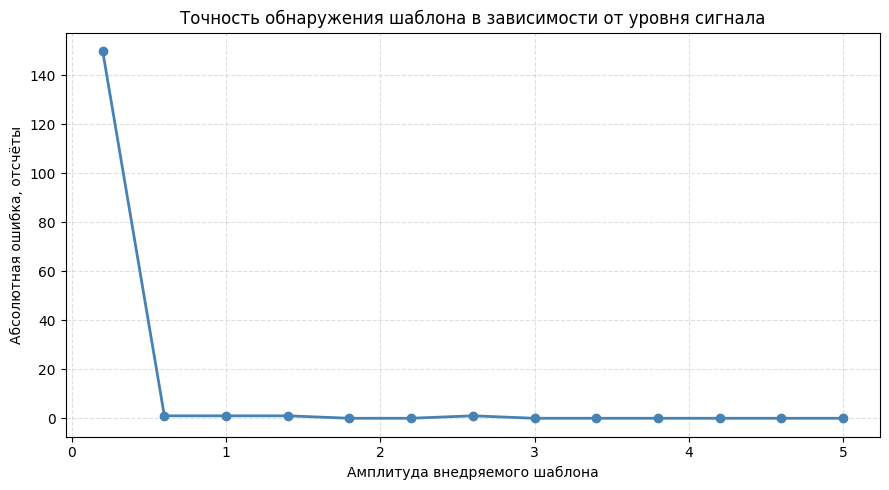

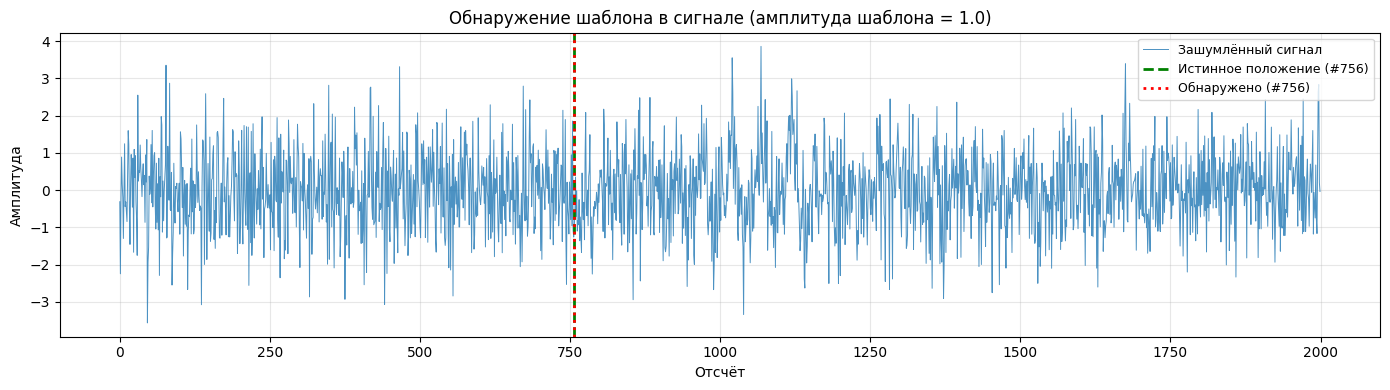

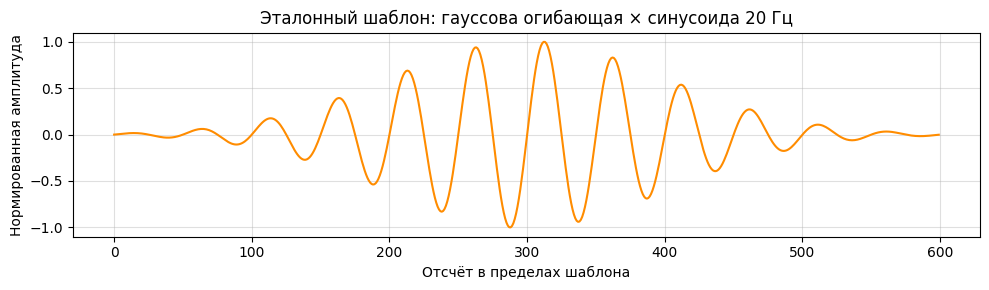

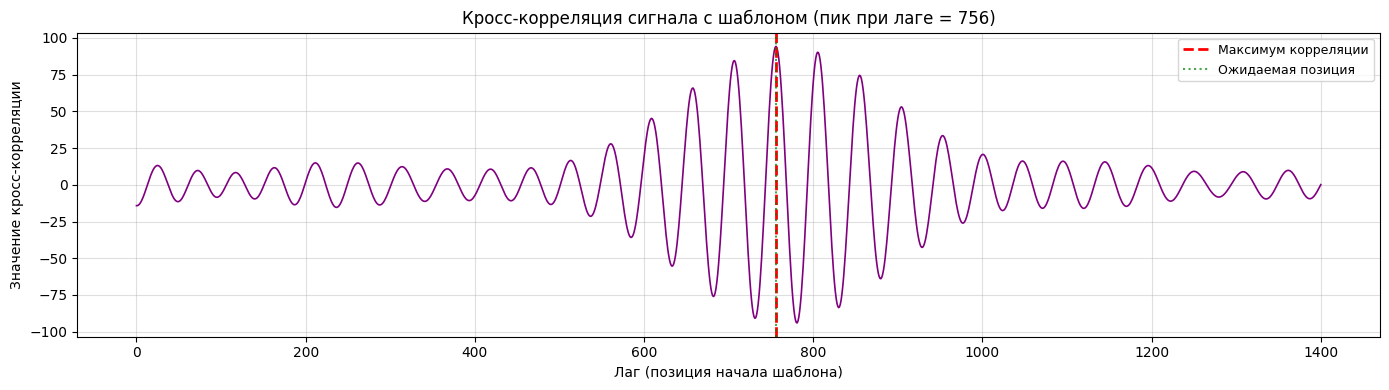

In [41]:

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


SAMPLING_FREQ = 1000          # Частота дискретизации, Гц
SIGNAL_DURATION = 2000        # Длина анализируемого сигнала, отсчёты
GAUSS_SIGMA = 100             # Параметр гауссовой огибающей, отсчёты
CARRIER_FREQ = 20             # Частота несущей синусоиды, Гц
TEMPLATE_SCALE = 6            # Коэффициент длины шаблона (≈6σ)
AMP_RANGE = np.arange(0.2, 5.1, 0.4)  # Диапазон амплитуд шаблона
VISUALIZATION_AMP = 1.0       # Амплитуда для демонстрационных графиков



def create_gaussian_sine_template(length, sigma, freq, fs):
    time_axis = np.arange(length)
    center_idx = length // 2

    envelope = np.exp(-np.power(time_axis - center_idx, 2) / (2 * sigma**2))

    carrier = np.sin(2 * np.pi * freq * time_axis / fs)

    template_raw = envelope * carrier
    return template_raw / np.max(np.abs(template_raw))


def inject_template_into_noise(signal_len, template, amplitude, rng):
    # Белый гауссов шум с единичной дисперсией
    composite_signal = rng.standard_normal(signal_len)

    # Случайная позиция для вставки (с учётом длины шаблона)
    template_len = len(template)
    max_pos = signal_len - template_len
    insert_position = rng.integers(0, max_pos)

    # Добавление шаблона с заданной амплитудой
    end_idx = insert_position + template_len
    composite_signal[insert_position:end_idx] += amplitude * template

    return composite_signal, insert_position


def estimate_template_position(signal, template):

    # Кросс-корреляция в режиме 'valid' (только полные перекрытия)
    correlation_result = np.correlate(signal, template, mode='valid')

    # Пик корреляции соответствует наилучшему совпадению
    return np.argmax(correlation_result)


def calculate_snr(signal, template, position, amplitude):

    template_len = len(template)
    signal_power = np.mean(template**2) * amplitude**2
    # Шум имеет дисперсию 1 (np.random.randn)
    noise_power = 1.0
    return 10 * np.log10(signal_power / noise_power) if noise_power > 0 else np.inf




# Инициализация генератора
rng = np.random.default_rng(RANDOM_STATE)

# Генерация шаблона
tmpl_length = int(TEMPLATE_SCALE * GAUSS_SIGMA)
reference_template = create_gaussian_sine_template(
    tmpl_length, GAUSS_SIGMA, CARRIER_FREQ, SAMPLING_FREQ
)

results = {
    'amplitudes': [],
    'true_pos': [],
    'estimated_pos': [],
    'abs_error': [],
    'snr_db': []
}

print(f"{'Амплитуда':>9} | {'SNR, дБ':>8} | {'Истинная':>8} | {'Найдена':>7} | {'Ошибка':>6}")
print("-" * 50)

for amp in AMP_RANGE:
    # Генерация зашумлённого сигнала с внедрённым шаблоном
    test_signal, ground_truth_pos = inject_template_into_noise(
        SIGNAL_DURATION, reference_template, amp, rng
    )

    # Оценка позиции шаблона
    detected_position = estimate_template_position(test_signal, reference_template)

    # Метрики
    position_error = np.abs(detected_position - ground_truth_pos)
    current_snr = calculate_snr(test_signal, reference_template, ground_truth_pos, amp)

    # Сохранение результатов
    results['amplitudes'].append(amp)
    results['true_pos'].append(ground_truth_pos)
    results['estimated_pos'].append(detected_position)
    results['abs_error'].append(position_error)
    results['snr_db'].append(current_snr)

    # Вывод строки результатов
    print(f"{amp:9.2f} | {current_snr:8.1f} | {ground_truth_pos:8d} | {detected_position:7d} | {position_error:6d}")


plt.figure(figsize=(9, 5))
plt.plot(results['amplitudes'], results['abs_error'],
         marker='o', linewidth=2, markersize=6, color='steelblue')
plt.xlabel('Амплитуда внедряемого шаблона')
plt.ylabel('Абсолютная ошибка, отсчёты')
plt.title('Точность обнаружения шаблона в зависимости от уровня сигнала')
plt.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

# отдельный пример (с фиксированным seed)
demo_rng = np.random.default_rng(RANDOM_STATE + 100)
demo_signal, demo_true_pos = inject_template_into_noise(
    SIGNAL_DURATION, reference_template, VISUALIZATION_AMP, demo_rng
)
demo_corr = np.correlate(demo_signal, reference_template, mode='valid')
demo_detected_pos = np.argmax(demo_corr)

# График 1: Исходный сигнал с отмеченными позициями
plt.figure(figsize=(14, 4))
plt.plot(demo_signal, linewidth=0.7, label='Зашумлённый сигнал', alpha=0.8)
plt.axvline(x=demo_true_pos, color='green', linestyle='--',
            linewidth=2, label=f'Истинное положение (#{demo_true_pos})')
plt.axvline(x=demo_detected_pos, color='red', linestyle=':',
            linewidth=2, label=f'Обнаружено (#{demo_detected_pos})')
plt.xlabel('Отсчёт')
plt.ylabel('Амплитуда')
plt.title(f'Обнаружение шаблона в сигнале (амплитуда шаблона = {VISUALIZATION_AMP})')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# График 2: Форма шаблона
plt.figure(figsize=(10, 3))
plt.plot(reference_template, color='darkorange', linewidth=1.5)
plt.xlabel('Отсчёт в пределах шаблона')
plt.ylabel('Нормированная амплитуда')
plt.title('Эталонный шаблон: гауссова огибающая × синусоида 20 Гц')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# График 3: Функция кросс-корреляции
plt.figure(figsize=(14, 4))
plt.plot(demo_corr, color='purple', linewidth=1.2)
plt.axvline(x=demo_detected_pos, color='red', linestyle='--',
            linewidth=2, label='Максимум корреляции')
# Истинная позиция в координатах корреляции
plt.axvline(x=demo_true_pos, color='green', linestyle=':',
            linewidth=1.5, alpha=0.7, label='Ожидаемая позиция')
plt.xlabel('Лаг (позиция начала шаблона)')
plt.ylabel('Значение кросс-корреляции')
plt.title(f'Кросс-корреляция сигнала с шаблоном (пик при лаге = {demo_detected_pos})')
plt.legend(fontsize=9)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

{
  Резкое ухудшение наблюдается при SNR = –22.2 дБ: ошибка составила 150 отсчётов. При SNR ≥ –12.7 дБ ошибка не превышает 1 отсчёта, то есть метод работает надёжно. Это происходит потому что при очень низком SNR пик кросс-корреляции от полезного сигнала становится сравним по высоте со случайными выбросами шума, поэтому функция argmax() начинает выбирать ложный максимум.
  }

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [42]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-19 23:17:03--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-19 23:17:04--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.09s   

2026-04-19 23:17:04 (74.7 MB/s) - ‘full_audio.wav’ saved [6990446/6

/tmp/ipykernel_2839/2089394553.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, full = wavfile.read('full_audio.wav')
/tmp/ipykernel_2839/2089394553.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, frag = wavfile.read('fragment.wav')


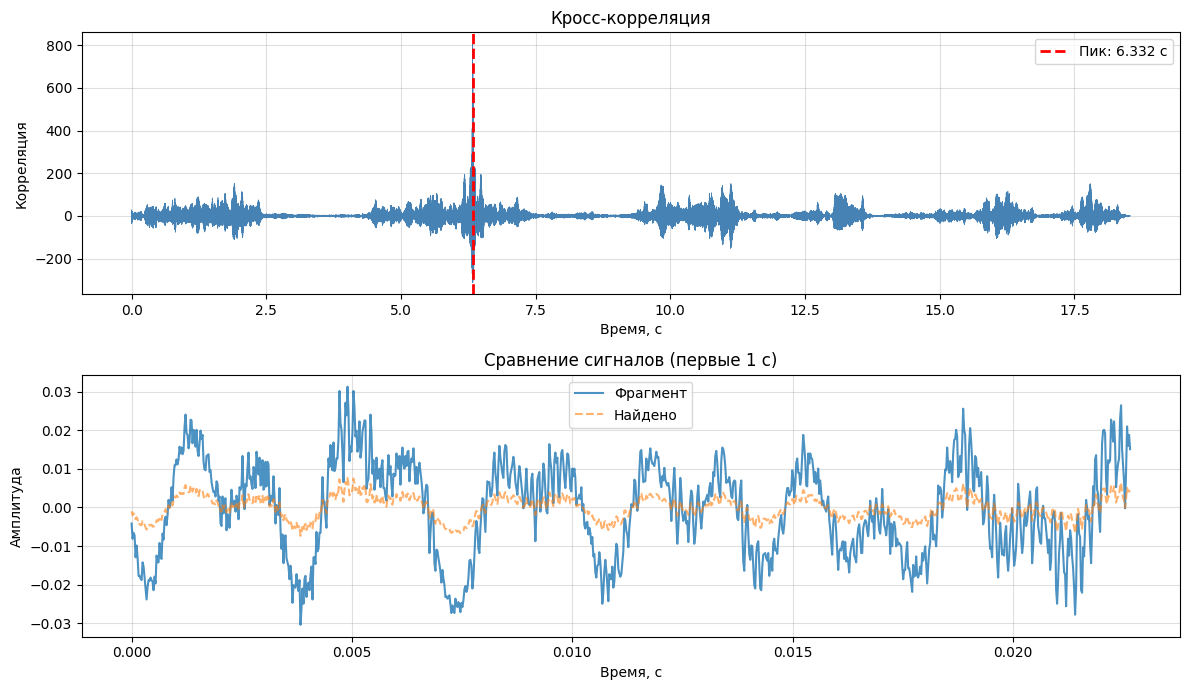

Исходный фрагмент:


Найденный участок (с 6.332 с)
Смещение в отсчётах: 279235


In [43]:
from scipy.io import wavfile
from scipy.signal import correlate
from IPython.display import Audio, display


fs_full, full = wavfile.read('full_audio.wav')
fs_frag, frag = wavfile.read('fragment.wav')

def to_mono_normalized(signal):
    if len(signal.shape) > 1:
        signal = signal.mean(axis=1)
    signal = signal.astype(np.float64)
    return signal / np.max(np.abs(signal))

full = to_mono_normalized(full)
frag = to_mono_normalized(frag)



corr = correlate(full, frag, mode='valid')
peak_idx = np.argmax(corr)  # ищем максимум, а не модуль!
time_offset = peak_idx / fs_full


t_corr = np.arange(len(corr)) / fs_full

plt.figure(figsize=(12, 7))

# График корреляции с осью ВРЕМЕНИ
plt.subplot(2, 1, 1)
plt.plot(t_corr, corr, color='steelblue', linewidth=0.5)
plt.axvline(time_offset, color='red', linestyle='--', linewidth=2,
            label=f'Пик: {time_offset:.3f} с')
plt.xlabel('Время, с')
plt.ylabel('Корреляция')
plt.title('Кросс-корреляция')
plt.legend()
plt.grid(alpha=0.4)

# Сравнение фрагмента и найденного участка
plt.subplot(2, 1, 2)
extracted = full[peak_idx:peak_idx + len(frag)]
plot_n = min(1000, len(frag))
t_plot = np.arange(plot_n) / fs_full

plt.plot(t_plot, frag[:plot_n], label='Фрагмент', alpha=0.8)
plt.plot(t_plot, extracted[:plot_n], label='Найдено', alpha=0.6, linestyle='--')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Сравнение сигналов (первые 1 с)')
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()


print("Исходный фрагмент:")
display(Audio(frag, rate=fs_frag))

time_offset_samples = peak_idx

print(f"Найденный участок (с {time_offset:.3f} с)")
print(f"Смещение в отсчётах: {time_offset_samples}")

display(Audio(extracted, rate=fs_full))


**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

{
  - Нормализация нужна, чтобы акцентировать внимание на форме сигнала, а не его амплитуде. Если не нормализовать, то громкий сигнал всегда будет давать бóльшую корреляцию, чем тихий, даже если форма совсем не похожа.
  - в этом коде фрагмент обнаруживается с помощью кросс-корреляции по глобальному максимуму функции корреляции. Для поиска нескольких вхождений сигнала необходимо дополнительно анализировать локальные максимумы. При наличии шума (низкий SNR) и похожих участков сигнала могут появляться ложные локальные максимумы корреляции, однако здесь они не превышают глобальный максимум и не приводят к ошибке.
  - Корреляция всё равно выдаст максимум, но это будет случайный и слабый локальный максимум}